In [83]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [84]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,7883757,"""posx"""
7661,5627,7883757,"""posx"""
7661,5628,7883757,"""posx"""
7661,5629,7883757,"""posx"""
7661,5630,7883757,"""posx"""
…,…,…,…
40,2454,10549449,"""posx"""
40,2455,10549449,"""posx"""
40,2456,10549449,"""posx"""


In [85]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

manual_db_agg

manual_detect_boulder_id,manual_boulder_size
u32,u32
1411612,58
559319,128
5013688,111
6612068,33423
8143751,16019
…,…
16263207,458
3680456,283270
267780,107


In [86]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
566518,15,32,0,"""""",5632,68617,0.000431
8375233,22,22,0,"""""",7168,34521,0.000528
15675192,1032916,198,4,"""BAAC""",444,217078,0.000911
566518,1055251,127,3,"""BAB""",144,68617,0.00185
14765514,1055424,123,3,"""BAB""",240,21406,0.005715
…,…,…,…,…,…,…,…
7883757,3634741,115,4,"""DCDA""",115,23444,0.004905
7883757,3646317,30,4,"""DCDB""",42,23444,0.001279
6288700,3787063,104,4,"""DDBD""",104,20255,0.005135


In [87]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

db_jaccard_agg

lod_level,manual_detect_boulder_id,row_id,overlap,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index,viewport_size,area_diff_factor
u8,u32,u32,u32,str,u32,u32,f64,u32,f64
4,5505284,751044,315,"""ADAA""",319,17330,0.018172,17330,0.018407
2,9522572,3174712,928,"""DB""",928,107075,0.008667,6692,0.008667
3,7831968,2123991,171,"""CAD""",176,234,0.715481,58,0.752137
3,4600381,1629662,525,"""BCD""",552,663,0.76087,165,0.832579
1,12587705,19808,13821,"""A""",40000,14843,0.336917,231,2.694873
…,…,…,…,…,…,…,…,…,…
4,798910,3239867,152,"""DBAD""",152,33284,0.004567,33284,0.004567
3,5844733,1102282,1153,"""BAC""",1164,1283,0.891036,320,0.907249
3,2501858,2381537,103,"""CBD""",592,173,0.155589,43,3.421965


In [88]:
from scipy.stats import gaussian_kde

db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

plotting_alphas = np.geomspace(1, 512**2, 500)
plotting_alphas_log = np.log(plotting_alphas)

def get_s_KDE(j_min, alpha_inputs : np.ndarray):
    alphas_pass = alphas[j > j_min]

    log_alphas = np.log(alphas)
    log_alphas_pass = np.log(alphas_pass)

    log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas)(np.log(alpha)) / alpha
    log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass)(np.log(alpha)) / alpha

    return log_alphas_pass_kde(alpha_inputs) / log_alphas_kde(alpha_inputs)
    

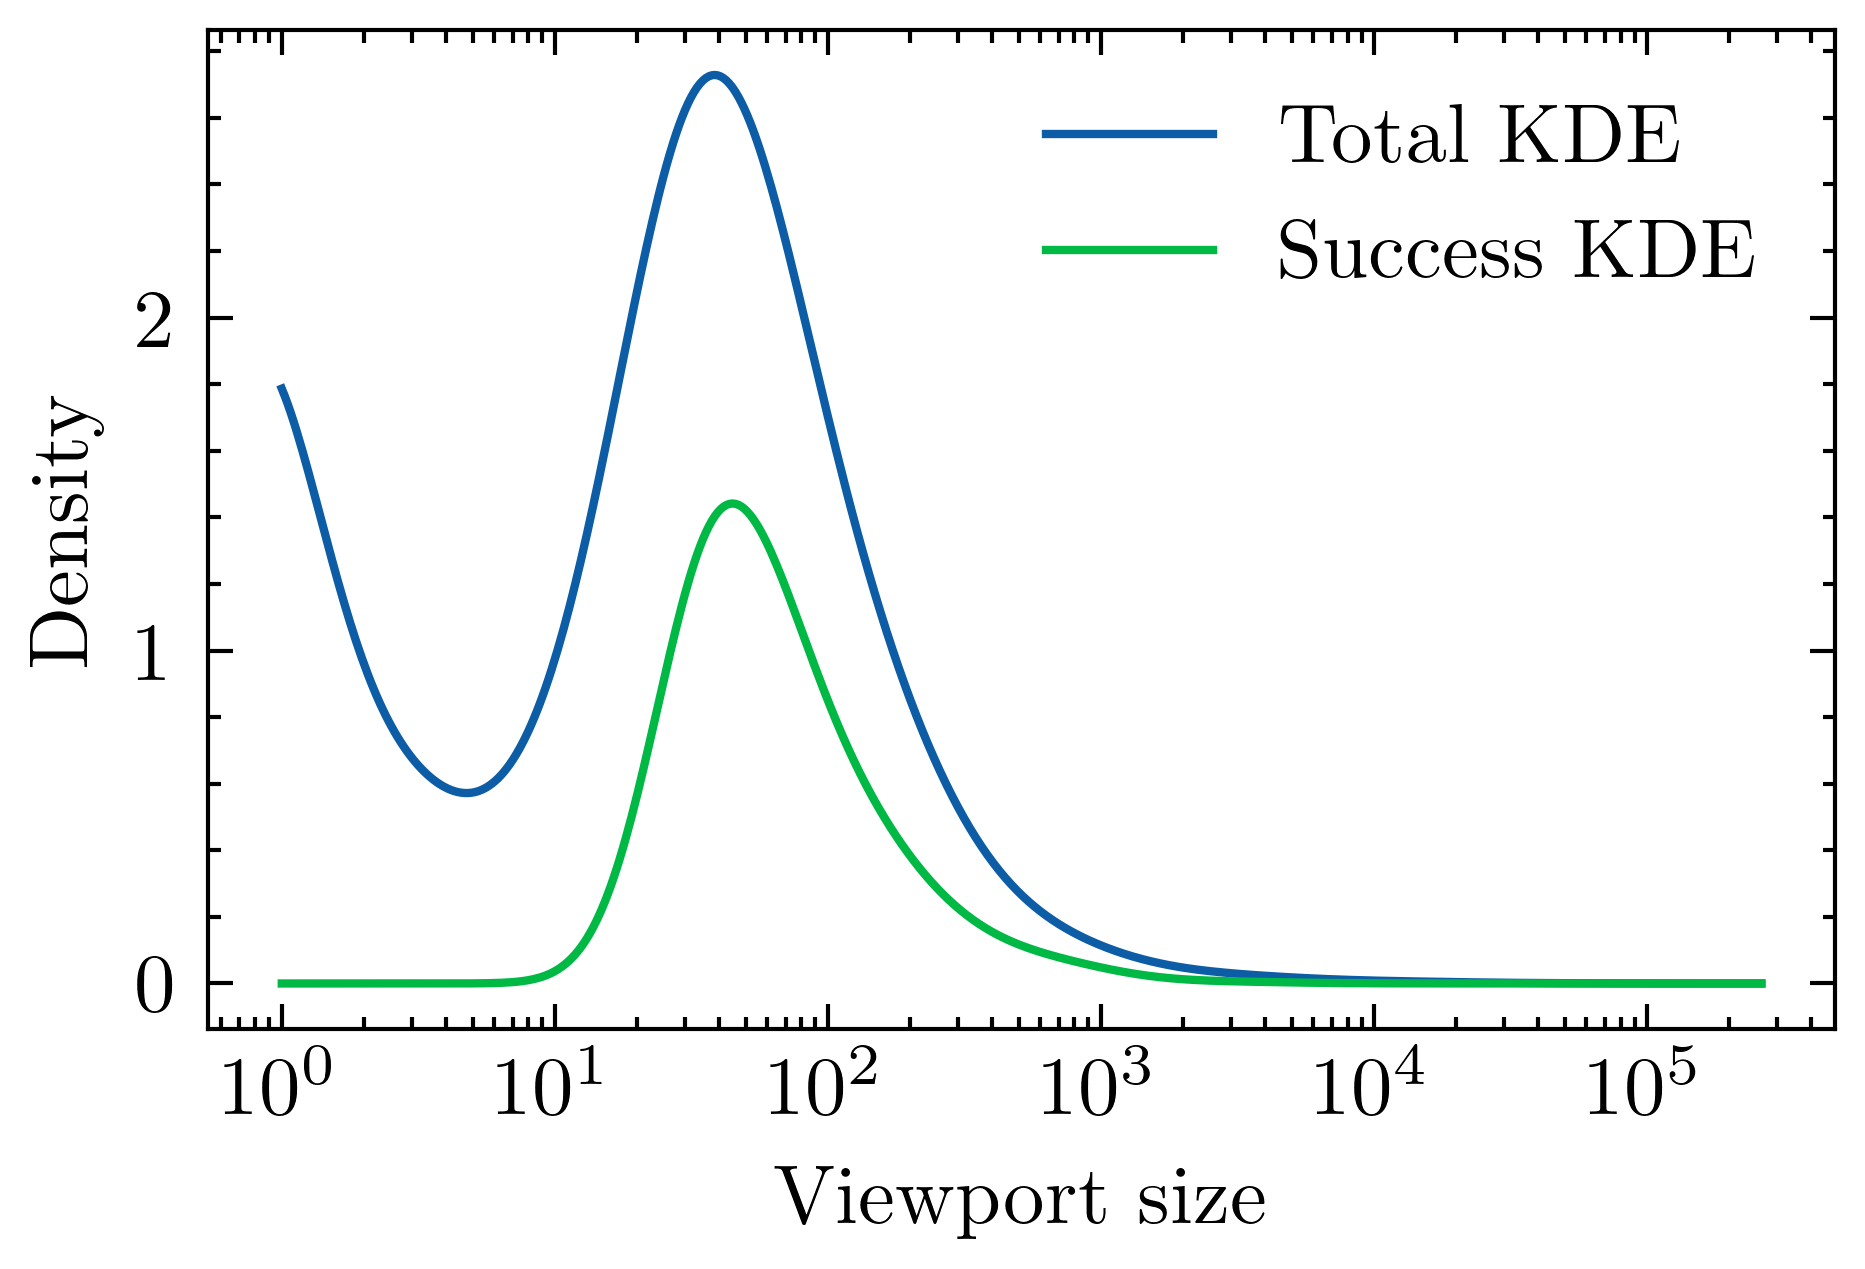

In [89]:
import numpy as np
import matplotlib.pyplot as plt

db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

plotting_alphas = np.geomspace(1, 512**2, 500)
plotting_alphas_log = np.log(plotting_alphas)

alphas_pass = alphas[j > 0.7]

log_alphas = np.log(alphas)
log_alphas_pass = np.log(alphas_pass)

log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas)(np.log(alpha)) / alpha
log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass)(np.log(alpha)) / alpha

plt.plot(plotting_alphas, log_alphas_kde(plotting_alphas), label="Total KDE")
plt.plot(plotting_alphas, log_alphas_pass_kde(plotting_alphas), label="Success KDE")

plt.xscale("log")
plt.xlabel("Viewport size")
plt.ylabel("Density")
plt.legend()
plt.show()

In [95]:
for j_min_plot in [0.4, 0.5, 0.6, 0.7, 0.7]:
    plt.plot(plotting_alphas, get_s_KDE(j_min_plot, plotting_alphas), label=rf"$J > {j_min_plot}$")


plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel(r"\alpha")
plt.ylabel(r"$S(\alpha)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig("S_from_manual_detection.png")
plt.show()

RuntimeError: latex was not able to process the following string:
b'\\\\alpha'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (MiKTeX 25.12) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2025-12-24>
(C:\Users\Joshu\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\Joshu\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\Joshu\AppData\Roaming\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\Joshu\AppData\Roaming\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\Joshu\AppData\Local\Programs\MiKTeX\tex/latex/base\t1cmr.fd))
(C:\Users\Joshu\AppData\Local\Programs\MiKTeX\tex/latex/base\inputenc.sty)
(C:\Users\Joshu\AppData\Roaming\MiKTeX\tex/latex/geometry\geometry.sty
(C:\Users\

RuntimeError: latex was not able to process the following string:
b'\\\\alpha'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (MiKTeX 25.12) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2025-12-24>
(C:\Users\Joshu\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\Joshu\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\Joshu\AppData\Roaming\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\Joshu\AppData\Roaming\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\Joshu\AppData\Local\Programs\MiKTeX\tex/latex/base\t1cmr.fd))
(C:\Users\Joshu\AppData\Local\Programs\MiKTeX\tex/latex/base\inputenc.sty)
(C:\Users\Joshu\AppData\Roaming\MiKTeX\tex/latex/geometry\geometry.sty
(C:\Users\

<Figure size 2100x1297.87 with 1 Axes>